# Minimizer density comparison

## Setup

### Imports

In [2]:
import os
import sys
import random
import hashlib
import math
import cmath
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from decimal import Decimal, getcontext
from tqdm import tqdm
from joblib import Parallel, delayed
getcontext().prec = 100

# Print Python and package versions
print(f"Python: {sys.version}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
import importlib.metadata
print(f"tqdm: {importlib.metadata.version('tqdm')}")
print(f"joblib: {importlib.metadata.version('joblib')}")

Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
numpy: 2.4.2
pandas: 2.3.0
matplotlib: 3.10.3
tqdm: 4.67.1
joblib: 1.3.2


### Measure density

In [3]:
# ----- Tiebreaking: get_kmer_id_dna (used by density) -----
def hash_kmer(k, kmer, seed):
    kmer_seed_sum = kmer + seed
    kmer_as_bytes = kmer_seed_sum.to_bytes(2 * k, byteorder='big')
    hashed_kmer = hashlib.sha256(kmer_as_bytes).digest()
    return int.from_bytes(hashed_kmer, byteorder='big')


def get_kmer_id_dna(k, kmer, seed):
    hashed_kmer = hash_kmer(k, kmer, seed) % (4 ** k)
    return (4 ** k) * hashed_kmer + kmer


# ----- Density sampling (DNA, includes tiebreaking) -----
# Two-phase: (1) build k-mers from sequence and assign ranks to all; (2) sliding window over rank array.
def random_density_function_dna_includes_tiebreaking(w, k, function, n_samples=10000, seed=1):
    """Estimate density: assign ranks to all k-mers in sequence, then slide over rank array to count sampled positions."""
    k_mask = (1 << (2 * k)) - 1
    total_nucleotides = n_samples + w + k - 1
    rng = np.random.default_rng(seed)
    nucleotides = rng.integers(0, 4, size=total_nucleotides, dtype=np.uint32)

    # Phase 1: build array of all k-mers (Python ints)
    n_kmers = total_nucleotides - k + 1
    kmers = []
    kmer = 0
    for pos in range(k):
        kmer = (kmer << 2) | int(nucleotides[pos])
    kmers.append(kmer & k_mask)
    for i in range(1, n_kmers):
        kmer = ((kmer << 2) | int(nucleotides[i + k - 1])) & k_mask
        kmers.append(kmer)

    # Phase 2: assign rank to every k-mer (rank = minimizer_rank << 8k + tiebreak_id)
    shift_8k = 8 * k
    ranks = [
        (function(km, w, k, seed) << shift_8k) + get_kmer_id_dna(k, km, seed)
        for km in kmers
    ]

    # Phase 3: sliding window over rank array; count when minimizer position changes
    sampled_positions = 0
    last_sampled = -1
    for t in range(n_samples):
        window = ranks[t : t + w]
        min_pos = t + window.index(min(window))
        if min_pos != last_sampled:
            sampled_positions += 1
            last_sampled = min_pos

    return sampled_positions / n_kmers  # density = minimizer positions / all k-mers

In [4]:
# ----- CPU count: prefer physical cores for CPU-bound parallel work -----
def _physical_cpu_count():
    try:
        import psutil
        return psutil.cpu_count(logical=False) or os.cpu_count() or 1
    except Exception:
        return os.cpu_count() or 1


def _effective_n_jobs(n_jobs):
    """-1 => physical core count; 1 => 1; else use as-is."""
    if n_jobs == -1:
        return _physical_cpu_count()
    return n_jobs


# ----- Helpers for scheme vs raw function (used by sampling) -----
def _scheme_name(scheme):
    """Display name for a scheme (MinimizerScheme instance or raw function)."""
    return scheme.name if hasattr(scheme, "name") else scheme.__name__


def _scheme_minimizer_for_repeat(scheme, repeat_seed):
    """Return minimizer function for this repeat. OC/Miniception use repeat_seed for inner order."""
    if hasattr(scheme, "get_minimizer"):
        return scheme.get_minimizer(seed=repeat_seed)
    return scheme


# ----- Sampling: fixed w, vary k (returns DataFrame) -----
def _run_one_density(w, k, minimizer_func, n_samples, seed):
    """Single density run (for parallel dispatch)."""
    return random_density_function_dna_includes_tiebreaking(w, k, minimizer_func, n_samples, seed=seed)


def _compute_row_fixed_w(w, k, schemes, n_samples, repeats, n_jobs_inner):
    """Compute one row (all schemes) for fixed w and given k. Used for outer parallel."""
    row = {"w": w, "k": k}
    for scheme in schemes:
        name = _scheme_name(scheme)
        tasks = [delayed(_run_one_density)(w, k, _scheme_minimizer_for_repeat(scheme, i), n_samples, i) for i in range(repeats)]
        densities = Parallel(n_jobs=_effective_n_jobs(n_jobs_inner))(tasks)
        row[name] = np.mean(densities) * (w + 1)
    return row


def _compute_row_fixed_k(k, w, schemes, n_samples, repeats, n_jobs_inner):
    """Compute one row (all schemes) for fixed k and given w."""
    row = {"w": w, "k": k}
    for scheme in schemes:
        name = _scheme_name(scheme)
        tasks = [delayed(_run_one_density)(w, k, _scheme_minimizer_for_repeat(scheme, i), n_samples, i) for i in range(repeats)]
        densities = Parallel(n_jobs=_effective_n_jobs(n_jobs_inner))(tasks)
        row[name] = np.mean(densities) * (w + 1)
    return row


def sample_density_fixed_w(w, schemes, k_range, n_samples=10000, repeats=5, n_jobs=-1):
    """Sample density for fixed w and varying k. n_jobs: -1 = physical cores (parallel over k), 1 = sequential."""
    k_list = list(k_range)
    if n_jobs == 1:
        rows = [_compute_row_fixed_w(w, k, schemes, n_samples, repeats, n_jobs_inner=-1) for k in tqdm(k_list, desc=f"fixed w={w}", unit="k")]
    else:
        rows = Parallel(n_jobs=_effective_n_jobs(n_jobs))(delayed(_compute_row_fixed_w)(w, k, schemes, n_samples, repeats, n_jobs_inner=1) for k in tqdm(k_list, desc=f"fixed w={w}", unit="k"))
    return pd.DataFrame(rows)


# ----- Sampling: fixed k, vary w (returns DataFrame) -----
def sample_density_fixed_k(k, schemes, w_range, n_samples=10000, repeats=5, n_jobs=-1):
    """Sample density for fixed k and varying w. n_jobs: -1 = physical cores (parallel over w), 1 = sequential."""
    w_list = list(w_range)
    if n_jobs == 1:
        rows = [_compute_row_fixed_k(k, w, schemes, n_samples, repeats, n_jobs_inner=-1) for w in tqdm(w_list, desc=f"fixed k={k}", unit="w")]
    else:
        rows = Parallel(n_jobs=_effective_n_jobs(n_jobs))(delayed(_compute_row_fixed_k)(k, w, schemes, n_samples, repeats, n_jobs_inner=1) for w in tqdm(w_list, desc=f"fixed k={k}", unit="w"))
    return pd.DataFrame(rows)


def sample_density_k_equals_w_plus_2(schemes, k_range, n_samples=10000, repeats=5, n_jobs=-1):
    """Sample density where w = k - 2, varying k. n_jobs: -1 = physical cores, 1 = sequential."""
    k_list = list(k_range)
    if n_jobs == 1:
        rows = [_compute_row_fixed_k(k, k - 2, schemes, n_samples, repeats, n_jobs_inner=-1) for k in tqdm(k_list, desc="w = k - 2", unit="k")]
    else:
        rows = Parallel(n_jobs=_effective_n_jobs(n_jobs))(delayed(_compute_row_fixed_k)(k, k - 2, schemes, n_samples, repeats, n_jobs_inner=1) for k in tqdm(k_list, desc="w = k - 2", unit="k"))
    return pd.DataFrame(rows)

### Plots

In [5]:
# ----- Lower bound (DNA sigma=4), same as scripts/plots.py -----
def _find_first_mod_1_after_x(x, w):
    remainder = x % w
    to_add = 1 if remainder == 0 else w - remainder + 1
    return x + to_add


def _is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(Decimal(n).sqrt()) + 1):
        if n % i == 0:
            return False
    return True


def _mobius(n):
    if n == 1:
        return 1
    p = 0
    for i in range(2, n):
        if n % i == 0:
            if not _is_prime(i):
                continue
            if (n // i) % i == 0:
                return 0
            p += 1
    if n > 1 and _is_prime(n):
        p += 1
    return -1 if p % 2 else 1


def _aperiodic_necklaces(p, sigma):
    return sum(_mobius(p // d) * sigma**d for d in range(1, p + 1) if p % d == 0) // p


def _get_lower_bound_improved(sigma, w, k):
    w, k, sigma = int(w), int(k), int(sigma)
    first_term = Decimal(1) / (Decimal(sigma) ** (w + k))
    divisors = [d for d in range(1, w + k + 1) if (w + k) % d == 0]
    sum_terms = sum(_aperiodic_necklaces(d, sigma) * np.ceil(d / w) for d in divisors)
    return float(first_term * Decimal(sum_terms))


def get_lower_bound_final(sigma, w, k):
    r1 = _get_lower_bound_improved(sigma, w, k)
    k2 = _find_first_mod_1_after_x(k, w)
    r2 = _get_lower_bound_improved(sigma, w, k2)
    return max(r1, r2)


SIGMA_DNA = 4


def plot_fixed_w_from_df(csv_path, w, k_min=None, k_max=None, use_density_factor=True, include_gm=False, y_range=None, show_legend=False, suppress_ylabel=False):
    """Plot vs k for fixed w. use_density_factor=True (default): plot density factor (density * (w+1)); False: plot density."""
    df = pd.read_csv(csv_path)
    if k_min is not None:
        df = df[df["k"] >= k_min]
    if k_max is not None:
        df = df[df["k"] <= k_max]
    k_vals = df["k"].values
    if use_density_factor:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w, k) * (w + 1) for k in k_vals]
        ylabel = "Density factor"
    else:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w, k) for k in k_vals]
        ylabel = "Density"
    plt.figure(figsize=(8.4, 6))
    for col in df.columns:
        if col in ("w", "k"):
            continue
        y = df[col] if use_density_factor else (df[col] / (w + 1))
        plt.plot(k_vals, y, marker='o', markersize=3, linestyle='-', label=col)
    
    if include_gm:
        gm_csv_path = None
        gm_label = "GreedyMini"
        if w == 24:
            gm_csv_path = "output/greedymini_density_all_wtest24.csv"
            if os.path.exists(gm_csv_path):
                df_gm = pd.read_csv(gm_csv_path)
                if k_min is not None:
                    df_gm = df_gm[df_gm["k"] >= k_min]
                if k_max is not None:
                    df_gm = df_gm[df_gm["k"] <= k_max]
                # align k_vals
                df_gm = df_gm[df_gm["k"].isin(k_vals)]
                if "lowest_value" in df_gm.columns:
                    gm_y = df_gm["lowest_value"].values
                    gm_k = df_gm["k"].values
                    if not use_density_factor:
                        gm_y = gm_y / (w + 1)
                    plt.plot(gm_k, gm_y, marker='o', markersize=3, linestyle=(0, (2, 2)), color='gray', label=gm_label)
        elif w == 12:
            gm_csv_path = "GM paper densities/k_extension_k16_w12.csv"
            if os.path.exists(gm_csv_path):
                df_gm = pd.read_csv(gm_csv_path, index_col="method")
                # Get GM methods (e.g. "GreedyMini", "GreedyMini 1", etc)
                gm_methods = [idx for idx in df_gm.index if isinstance(idx, str) and "GreedyMini" in idx]
                if gm_methods:
                    df_gm_only = df_gm.loc[gm_methods].dropna(axis=1, how='all')
                    # For each column (k value), get the minimum across all GM methods
                    gm_k_str = [col for col in df_gm_only.columns if col.isdigit()]
                    gm_k = np.array([int(k) for k in gm_k_str])
                    gm_y = df_gm_only[gm_k_str].min(axis=0).values
                    
                    if len(gm_k) > 0 and gm_k[-1] < 32:
                        extend_k = np.arange(gm_k[-1] + 1, 33)
                        extend_y = np.full(len(extend_k), gm_y[-1])
                        gm_k = np.concatenate((gm_k, extend_k))
                        gm_y = np.concatenate((gm_y, extend_y))
                    
                    # Filter by k bounds
                    mask = np.ones(len(gm_k), dtype=bool)
                    if k_min is not None:
                        mask &= (gm_k >= k_min)
                    if k_max is not None:
                        mask &= (gm_k <= k_max)
                    gm_k = gm_k[mask]
                    gm_y = gm_y[mask]
                    
                    # align with k_vals
                    align_mask = np.isin(gm_k, k_vals)
                    gm_k = gm_k[align_mask]
                    gm_y = gm_y[align_mask]
                    
                    if use_density_factor:
                        gm_y = gm_y * (w + 1)
                    plt.plot(gm_k, gm_y, marker='o', markersize=3, linestyle=(0, (2, 2)), color='gray', label=gm_label)
    
    if include_gm:
        gm_csv_path = "output/greedymini_density_all_wtest24.csv" # Will be updated if w=24 or whatever, wait, actually we are tying k to w+2 so we can't just pick wtest24. Actually, the file `output/greedymini_density_all_wtest24.csv` assumes w=24 always, which is false here, so we shouldn't plot it here.
        pass
        
    plt.plot(k_vals, lower_bound, linestyle='--', color='black', linewidth=2, label="Lower bound")
    plt.xlabel("k", fontsize=16)
    if not suppress_ylabel:
        plt.ylabel(ylabel, fontsize=16)
    
    ticks = [3, 5] + list(range(10, 31, 5)) + [32]
    ticks = [t for t in ticks if min(k_vals) <= t <= max(k_vals)]
    plt.xticks(ticks, fontsize=14)
    plt.yticks(fontsize=14)
    if y_range is not None:
        plt.ylim(y_range)
    if show_legend:
        plt.legend(fontsize=14)
    plt.grid(True)
    
    out_svg = csv_path.rsplit(".", 1)[0] + ".svg"
    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    print(f"Saved plot to {out_svg}")
    
    plt.show()


def plot_fixed_k_from_df(csv_path, k, w_min=None, w_max=None, use_density_factor=True, include_gm=False, y_range=None, show_legend=False, suppress_ylabel=False, add_circles=False):
    """Plot vs w for fixed k. use_density_factor=True (default): plot density factor (density * (w+1)); False: plot density."""
    df = pd.read_csv(csv_path)
    if w_min is not None:
        df = df[df["w"] >= w_min]
    if w_max is not None:
        df = df[df["w"] <= w_max]
    w_vals = df["w"].values
    if use_density_factor:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w, k) * (w + 1) for w in w_vals]
        ylabel = "Density factor"
    else:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w, k) for w in w_vals]
        ylabel = "Density"
    plt.figure(figsize=(8.4, 6))
    
    marker = 'o' if add_circles else None
    
    for col in df.columns:
        if col in ("w", "k"):
            continue
        y = df[col] if use_density_factor else (df[col] / (df["w"] + 1)).values
        plt.plot(w_vals, y, marker=marker, markersize=3, linestyle='-', label=col)
    if include_gm and k == 12:
        gm_w_all = []
        gm_y_all = []
        
        gm_csv_path1 = "GM paper densities/w_extension_k12.csv"
        if os.path.exists(gm_csv_path1):
            df_gm1 = pd.read_csv(gm_csv_path1, index_col="method")
            gm_methods = [idx for idx in df_gm1.index if isinstance(idx, str) and "GreedyMini" in idx]
            if gm_methods:
                df_gm_only = df_gm1.loc[gm_methods].dropna(axis=1, how='all')
                gm_w_str = [col for col in df_gm_only.columns if col.isdigit()]
                gm_w1 = np.array([int(w) for w in gm_w_str])
                gm_y1 = df_gm_only[gm_w_str].min(axis=0).values
                for w_val, y_val in zip(gm_w1, gm_y1):
                    gm_w_all.append(w_val)
                    gm_y_all.append(y_val)
                    
        gm_csv_path2 = "output/greedymini_density_all_ktest12.csv"
        if os.path.exists(gm_csv_path2):
            df_gm2 = pd.read_csv(gm_csv_path2)
            if "lowest_value" in df_gm2.columns:
                gm_w2 = df_gm2["w"].values
                gm_y2 = df_gm2["lowest_value"].values
                for w_val, y_val in zip(gm_w2, gm_y2):
                    if not np.isnan(y_val):
                        gm_w_all.append(w_val)
                        gm_y_all.append(y_val / (w_val + 1))  # new csv has density factors, convert to density
                        
        if gm_w_all:
            w_to_min_y = {}
            for w_val, y_val in zip(gm_w_all, gm_y_all):
                if w_val not in w_to_min_y or y_val < w_to_min_y[w_val]:
                    w_to_min_y[w_val] = y_val
                    
            gm_w = np.array(sorted(list(w_to_min_y.keys())))
            gm_y = np.array([w_to_min_y[w_val] for w_val in gm_w])
            
            if len(gm_w) > 0 and gm_w[-1] < 100:
                extend_w = np.arange(gm_w[-1] + 1, 101)
                extend_y = np.full(len(extend_w), gm_y[-1])
                gm_w = np.concatenate((gm_w, extend_w))
                gm_y = np.concatenate((gm_y, extend_y))
            
            mask = np.ones(len(gm_w), dtype=bool)
            if w_min is not None:
                mask &= (gm_w >= w_min)
            if w_max is not None:
                mask &= (gm_w <= w_max)
            gm_w = gm_w[mask]
            gm_y = gm_y[mask]
            
            align_mask = np.isin(gm_w, w_vals)
            gm_w = gm_w[align_mask]
            gm_y = gm_y[align_mask]
            
            if use_density_factor:
                gm_y = gm_y * (gm_w + 1)
            plt.plot(gm_w, gm_y, marker=marker, markersize=3, linestyle=(0, (2, 2)), color='gray', label="GreedyMini")
    
    plt.plot(w_vals, lower_bound, linestyle='--', color='black', linewidth=2, label="Lower bound")
    plt.xlabel("w", fontsize=16)
    if not suppress_ylabel:
        plt.ylabel(ylabel, fontsize=16)
    
    ticks = [3] + list(range(10, 101, 10))
    ticks = [t for t in ticks if min(w_vals) <= t <= max(w_vals)]
    plt.xticks(ticks, fontsize=14)
    plt.yticks(fontsize=14)
    if y_range is not None:
        plt.ylim(y_range)
    if show_legend:
        plt.legend(fontsize=14)
    plt.grid(True)
    
    out_svg = csv_path.rsplit(".", 1)[0] + ".svg"
    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    print(f"Saved plot to {out_svg}")
    
    plt.show()


def plot_k_tied_to_w_from_df(csv_path, k_min=None, k_max=None, use_density_factor=True, include_gm=False, y_range=None, show_legend=False, suppress_ylabel=False):
    """Plot vs k where w = k - 2. use_density_factor=True: plot density factor; False: plot density."""
    df = pd.read_csv(csv_path)
    if k_min is not None:
        df = df[df["k"] >= k_min]
    if k_max is not None:
        df = df[df["k"] <= k_max]
    
    k_vals = df["k"].values
    w_vals = df["w"].values  # Should be k - 2
    
    if use_density_factor:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w_vals[i], k_vals[i]) * (w_vals[i] + 1) for i in range(len(k_vals))]
        ylabel = "Density factor"
    else:
        lower_bound = [get_lower_bound_final(SIGMA_DNA, w_vals[i], k_vals[i]) for i in range(len(k_vals))]
        ylabel = "Density"
        
    plt.figure(figsize=(8.4, 6))
    for col in df.columns:
        if col in ("w", "k"):
            continue
        y = df[col] if use_density_factor else (df[col] / (w_vals + 1))
        plt.plot(k_vals, y, marker='o', markersize=3, linestyle='-', label=col)
        
    plt.plot(k_vals, lower_bound, linestyle='--', color='black', linewidth=2, label="Lower bound")
    plt.xlabel("k", fontsize=16)
    if not suppress_ylabel:
        plt.ylabel(ylabel, fontsize=16)
    
    ticks = [3, 5] + list(range(10, 31, 5)) + [32]
    ticks = [t for t in ticks if min(k_vals) <= t <= max(k_vals)]
    plt.xticks(ticks, fontsize=14)
    plt.yticks(fontsize=14)
    if y_range is not None:
        plt.ylim(y_range)
    if show_legend:
        plt.legend(fontsize=14)
    plt.grid(True)
    
    out_svg = csv_path.rsplit(".", 1)[0] + ".svg"
    plt.savefig(out_svg, format="svg", bbox_inches="tight")
    print(f"Saved plot to {out_svg}")
    
    plt.show()

## Minimizers

### Double Decycling

In [5]:
# ----- Double decycling (DNA) -----
_DD_BASE_WEIGHTS = (65, 67, 71, 84)  # C++ style: use number as-is (ASCII) - we used these weights in GreedyMini
# _DD_BASE_WEIGHTS = (0, 1, 2, 3)   # Default
_decycling_roots_cache = {}


def _get_decycling_roots(k):
    if k not in _decycling_roots_cache:
        _decycling_roots_cache[k] = [cmath.exp(2 * cmath.pi * 1j * i / k) for i in range(k)]
    return _decycling_roots_cache[k]


_DEPS = 1e-12


def get_decycling_set_dna(kmer, w, k):
    roots = _get_decycling_roots(k)
    x = sum(roots[i] * _DD_BASE_WEIGHTS[(kmer >> (2 * (k - 1 - i))) & 0b11] for i in range(k))
    mag = abs(x)
    if mag <= _DEPS:
        return 2  # Neither (arg undefined at origin; PMC "all rotations I(x)=0" edge case)
    angle = cmath.phase(x)
    two_pi_k = 2 * math.pi / k
    lo_pos = math.pi - two_pi_k - _DEPS
    lo_neg = -two_pi_k - _DEPS
    hi_neg = 0 + _DEPS
    if lo_pos <= angle <= math.pi + _DEPS:
        return 0  # Decycling-positive (Dk)
    if lo_neg <= angle <= hi_neg:
        return 1  # Decycling-negative (D~k)
    return 2  # Neither


def double_decycling_dna(kmer, w, k, seed=None):
    return get_decycling_set_dna(kmer, w, k)

### Miniception and open-closed

In [6]:
# Syncmer helpers: s-mer at position i (0..k-s) in DNA k-mer (2 bits per base)
def _smer_at(kmer, k, s, i):
    """Extract s-mer at start position i (0 = leftmost)."""
    shift = 2 * (k - s - i)
    mask = (1 << (2 * s)) - 1
    return (kmer >> shift) & mask


def _syncmer_class_dna(kmer, k, s):
    """
    Return (is_open, is_closed) for a k-mer.
    Closed: smallest s-mer at position 0 or k-s.
    Open: smallest s-mer at position v = (k-s)//2.
    """
    n_pos = k - s + 1
    if n_pos <= 0:
        return False, False
    smers = [(_smer_at(kmer, k, s, i), i) for i in range(n_pos)]
    min_val = min(s[0] for s in smers)
    min_positions = [i for v, i in smers if v == min_val]
    argmin = min_positions[0]  # leftmost min for tiebreak
    v_mid = (k - s) // 2
    is_closed = argmin == 0 or argmin == k - s
    is_open = argmin == v_mid
    return is_open, is_closed


def _syncmer_param_s(k, default_s=4):
    """Syncmer length s: min(default_s, k), at least 1."""
    return max(1, min(default_s, k))


def miniception_dna(kmer, w, k, seed=None):
    """
    Miniception: smallest closed syncmer in window; if none, smallest k-mer.
    Inner order (within class) uses seed so it is random between runs, constant within run.
    """
    s = _syncmer_param_s(k)
    is_open, is_closed = _syncmer_class_dna(kmer, k, s)
    run_seed = seed if seed is not None else 0
    inner_id = get_kmer_id_dna(k, kmer, run_seed)
    L = 1 << (8 * k)
    if is_closed:
        return 0 * L + inner_id
    return 1 * L + inner_id


def open_closed_dna(kmer, w, k, seed=None):
    """
    Open-closed (OC) minimizer: prefer open syncmer > closed syncmer > other.
    Inner order (within each class) uses seed: random between runs, constant within run.
    """
    s = _syncmer_param_s(k)
    is_open, is_closed = _syncmer_class_dna(kmer, k, s)
    run_seed = seed if seed is not None else 0
    inner_id = get_kmer_id_dna(k, kmer, run_seed)
    L = 1 << (8 * k)
    if is_open:
        return 0 * L + inner_id
    if is_closed:
        return 1 * L + inner_id
    return 2 * L + inner_id

### One-zero

In [7]:
# ----- One-zero (DNA) -----
def _lemma_1_order_rank(projection, k):
    order_list = []
    order_list.append((1 << k) - 2)
    order_list.append((1 << (k - 1)) - 2)
    for i in range(2, k - 1):
        order_list.append(2 * ((1 << (k - 1 - i)) - 1))
    order_list.append(1)
    order_list.append((1 << k) - 1)
    order_list.append(0)
    order_list = list(dict.fromkeys(order_list))
    rank_map = {p: r for r, p in enumerate(order_list)}
    return rank_map.get(projection, -1)


def _build_lemma_1_set(k):
    lemma_1_projs = {(1 << k) - 1, 0, 1, (1 << k) - 2}
    for i in range(2, k):
        ones_count = k - i
        pattern = ((1 << ones_count) - 1) << 1
        lemma_1_projs.add(pattern)
    return lemma_1_projs




def one_zero_minimizer_key(k, kmer):
    """Variant: tail/head boundary at first subsequent '10'. Projection = high bit per base (G/T=1, A/C=0), matching 4-ary 10-order."""
    projection = 0
    for i in range(k):
        nuc = (kmer >> (2 * (k - 1 - i))) & 0b11
        bit = 1 if nuc == 3 else 0
        projection = (projection << 1) | bit

    def get_bit(val, pos):
        return (val >> (k - 1 - pos)) & 1

    # Require leading '10' as in one_zero_minimizer_key
    if get_bit(projection, 0) == 1 and get_bit(projection, 1) == 0:
        head_len = 2
        prev = 0  # bit 1 is 0 here
        for i in range(2, k):
            curr = get_bit(projection, i)
            head_len += 1
            if prev == 1 and curr == 0:
                break
            prev = curr
        # if last bit is 1 then reduce head_len by 1 to account for 10000000000000000000001
        if (prev == 1):
            head_len -= 1

        tail_len = k - head_len
        tail_val = projection & ((1 << tail_len) - 1)
        return (0, head_len, tail_val)
        

    lemma_1_projs = _build_lemma_1_set(k)
    if projection in lemma_1_projs:
        return (1, _lemma_1_order_rank(projection, k))
    return (2, projection)


def one_zero_minimizer_rank(kmer, k):
    t = one_zero_minimizer_key(k, kmer)
    L = (1 << (2 * k)) + 1
    if t[0] == 0:
        head_len, tail_val = t[1], t[2]
        return 0 * (L ** 3) - (head_len) * (L ** 2) - (tail_val) * L + kmer
    elif t[0] == 1:
        rank_in_lemma_1 = t[1]
        return 1 * (L ** 3) + rank_in_lemma_1 * (L ** 2) + kmer
    else:
        return 2 * (L ** 3) - kmer


def one_zero_v2_dna(kmer, w, k, seed=None):
    return one_zero_minimizer_rank(kmer, k)

### ABB+

In [8]:
def abb_plus_score_dna(kmer, k):
    """Pos 0 lex (A<C<T<G); pos 1..k-1 non-A < A; tiebreak lex."""
    nuc0 = (kmer >> (2 * (k - 1))) & 0b11
    key = nuc0
    for i in range(1, k):
        nuc = (kmer >> (2 * (k - 1 - i))) & 0b11
        key = key * 2 + (1 if nuc == 0 else 0)
    return key * (1 << (2 * k)) + kmer


def abb_plus_dna(kmer, w, k, seed=None):
    """Minimizer using ABB+ rank only (no shift)."""
    return abb_plus_score_dna(kmer, k)

### Wrappers

In [9]:
class MinimizerScheme:
    """Base: .name and .get_minimizer(seed=None) -> (kmer, w, k, seed=None) -> rank."""

    name = "base"

    def get_minimizer(self, seed=None):
        raise NotImplementedError


class DoubleDecyclingScheme(MinimizerScheme):
    name = "double_decycling_dna"

    def get_minimizer(self, seed=None):
        def _fn(kmer, w, k, seed=None):
            return get_decycling_set_dna(kmer, w, k)
        return _fn


class MiniceptionScheme(MinimizerScheme):
    """Uses seed in get_minimizer(seed) for inner random order per run."""

    name = "miniception_dna"

    def get_minimizer(self, seed=None):
        run_seed = seed if seed is not None else 0

        def _fn(kmer, w, k, seed=None):
            return miniception_dna(kmer, w, k, run_seed)
        return _fn


class OpenClosedScheme(MinimizerScheme):
    """Uses seed in get_minimizer(seed) for inner random order per run."""

    name = "open_closed_dna"

    def get_minimizer(self, seed=None):
        run_seed = seed if seed is not None else 0

        def _fn(kmer, w, k, seed=None):
            return open_closed_dna(kmer, w, k, run_seed)
        return _fn


class OneZeroScheme(MinimizerScheme):
    name = "one_zero_dna"

    def get_minimizer(self, seed=None):
        def _fn(kmer, w, k, seed=None):
            return one_zero_minimizer_rank(kmer, k)
        return _fn



class ABBPlusScheme(MinimizerScheme):
    name = "abb_plus_dna"

    def get_minimizer(self, seed=None):
        def _fn(kmer, w, k, seed=None):
            return abb_plus_score_dna(kmer, k)
        return _fn

## Measure Density

In [10]:
# All DNA minimizers as schemes (name + get_minimizer(seed)); OC and Miniception use seed per run.
SCHEMES_DNA = [
    DoubleDecyclingScheme(),
    OneZeroScheme(),
    ABBPlusScheme(),
    MiniceptionScheme(),
    OpenClosedScheme(),
]
FUNCTIONS_DNA = SCHEMES_DNA  # alias for sampling/plots
FUNCTION_NAMES = [_scheme_name(s) for s in SCHEMES_DNA]

# Run all 4 experiments and save to CSV (no plotting)
N_SAMPLES = 2_000_000 
REPEATS = 5 # was 200
OUTPUT_DIR = "."


In [11]:
df_k12 = sample_density_fixed_k(12, FUNCTIONS_DNA, range(2, 101), n_samples=N_SAMPLES, repeats=REPEATS)
df_k12.to_csv(f"{OUTPUT_DIR}/density_fixed_k12.csv", index=False)
print("Saved density_fixed_k12.csv")

df_k24 = sample_density_fixed_k(24, FUNCTIONS_DNA, range(2, 101), n_samples=N_SAMPLES, repeats=REPEATS)
df_k24.to_csv(f"{OUTPUT_DIR}/density_fixed_k24.csv", index=False)
print("Saved density_fixed_k24.csv")

df_w12 = sample_density_fixed_w(12, FUNCTIONS_DNA, range(2, 33), n_samples=N_SAMPLES, repeats=REPEATS)
df_w12.to_csv(f"{OUTPUT_DIR}/density_fixed_w12.csv", index=False)
print("Saved density_fixed_w12.csv")

df_w24 = sample_density_fixed_w(24, FUNCTIONS_DNA, range(2, 33), n_samples=N_SAMPLES, repeats=REPEATS)
df_w24.to_csv(f"{OUTPUT_DIR}/density_fixed_w24.csv", index=False)
print("Saved density_fixed_w24.csv")

df_k_tied_w = sample_density_k_equals_w_plus_2(FUNCTIONS_DNA, range(3, 33), n_samples=N_SAMPLES, repeats=REPEATS)
df_k_tied_w.to_csv(f"{OUTPUT_DIR}/density_k_tied_w.csv", index=False)
print("Saved density_k_tied_w.csv")

fixed k=12:   0%|          | 0/99 [00:00<?, ?w/s]

KeyboardInterrupt: 

## Plots

Saved plot to density_fixed_k12_edited.svg


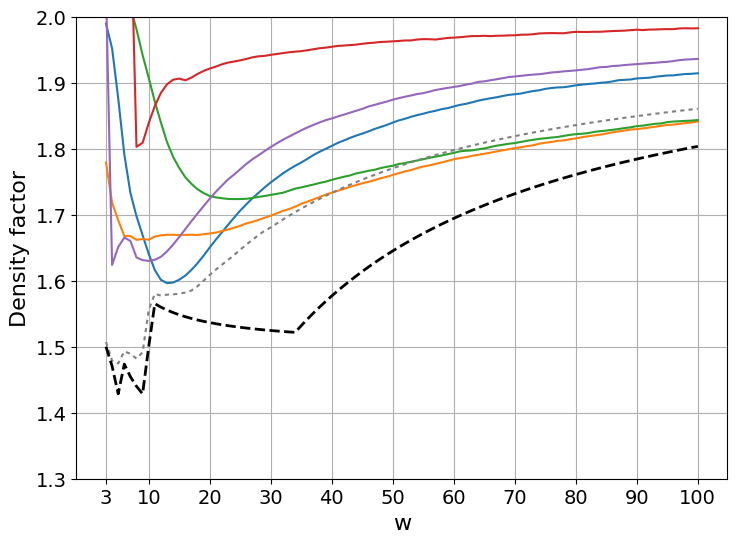

In [6]:
SHARED_RANGE_FIXED_K_PLOTS = (1.3, 2.0)
#plot_fixed_k_from_df("density_fixed_k12.csv", 12, w_min=2, w_max=100, use_density_factor=True, include_gm = True)
plot_fixed_k_from_df("density_fixed_k12_edited.csv", 12, w_min=3, w_max=100, use_density_factor=True, include_gm = True, y_range =SHARED_RANGE_FIXED_K_PLOTS)

Saved plot to density_fixed_k24_edited.svg


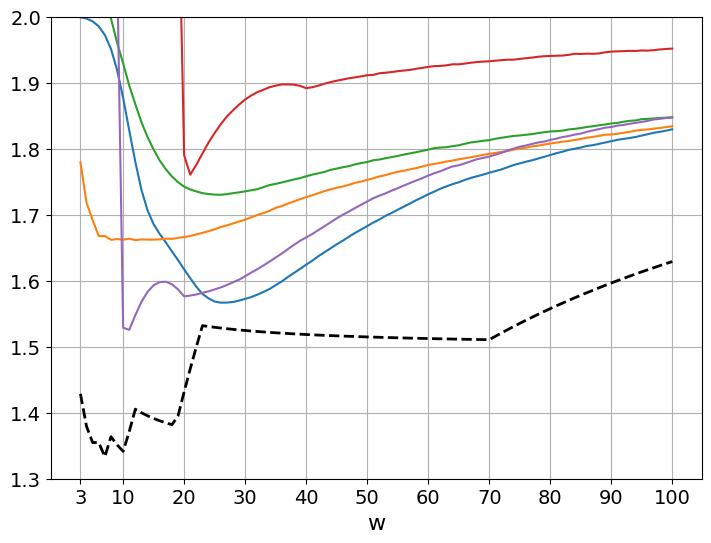

In [7]:
#plot_fixed_k_from_df("density_fixed_k24.csv", 24, w_min=2, w_max=100, include_gm = False)
plot_fixed_k_from_df("density_fixed_k24_edited.csv", 24, w_min=3, w_max=100, include_gm = False,  y_range =SHARED_RANGE_FIXED_K_PLOTS, suppress_ylabel=True)

Saved plot to density_fixed_w12_edited.svg


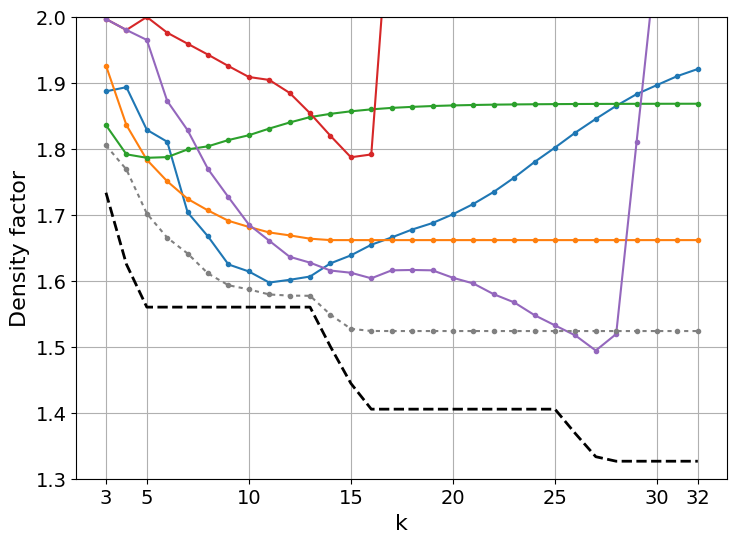

In [9]:
SHARED_RANGE_FIXED_W_PLOTS = (1.3, 2.0)

#plot_fixed_w_from_df("density_fixed_w12.csv", 12, k_min=3, k_max=32, include_gm = True)
plot_fixed_w_from_df("density_fixed_w12_edited.csv", 12, k_min=3, k_max=32, include_gm = True, y_range =SHARED_RANGE_FIXED_W_PLOTS)

Saved plot to density_fixed_w24_edited.svg


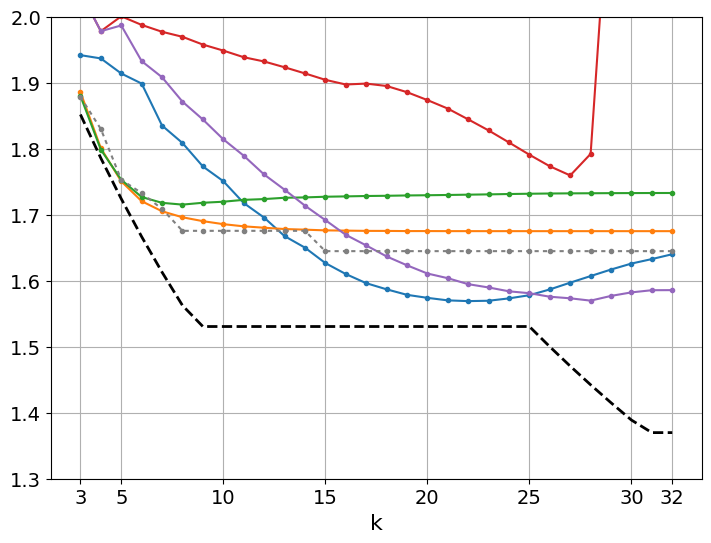

In [10]:
#plot_fixed_w_from_df("density_fixed_w24.csv", 24, k_min=3, k_max=30, use_density_factor=True, include_gm = True)
plot_fixed_w_from_df("density_fixed_w24_edited.csv", 24, k_min=3, k_max=32, use_density_factor=True, include_gm = True, y_range =SHARED_RANGE_FIXED_W_PLOTS, suppress_ylabel=True)

Saved plot to density_k_tied_w.svg


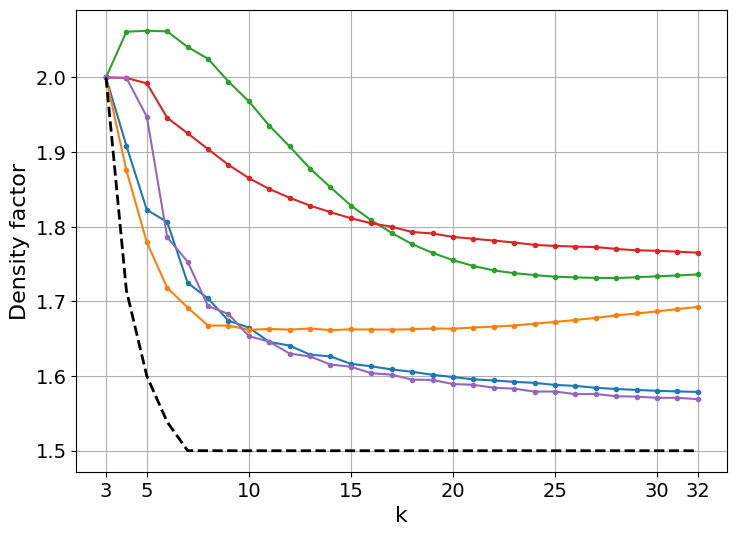

In [11]:
plot_k_tied_to_w_from_df("density_k_tied_w.csv", k_min=3, k_max=32)